# Spatial hot spots with Gaussian Mixture Models

This notebook identifies spatial taxi-demand hot spots with a Gaussian Mixture Model (GMM). This first section deliberately stops before model fitting. It establishes the spatial observations that will later enter the GMM.

Unit of observation: one taxi trip with a valid published pickup centroid. The published coordinates are privacy-protected area centroids, not exact pickup addresses. Repeated coordinates must therefore be retained: their frequency represents observed pickup demand at the published location.

For computationally repeated model comparisons, a fixed-size reservoir sample is drawn directly from the trip rows. Sampling trips rather than unique coordinates preserves the empirical demand weights. No artificial jitter is added.

In [1]:
from pathlib import Path
import sys

import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "run_config.py").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "notebooks"
if not (NOTEBOOK_DIR / "run_config.py").exists():
    raise FileNotFoundError("Could not locate notebooks/run_config.py")

sys.path.insert(0, str(NOTEBOOK_DIR))
from run_config import PATHS, RUN_MODE

pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

### Config

`EPSG:4326` contains longitude and latitude in degrees. A Gaussian model must operate on meaningful spatial distances, so the pickup points are projected to `EPSG:26916` (NAD83 / UTM zone 16N), whose axes are measured in metres around Chicago.

In [2]:
SAMPLE_SIZE = 250_000
RANDOM_SEED = 42
SOURCE_CRS = "EPSG:4326"
METRIC_CRS = "EPSG:26916"

TAXI_PATH = PATHS.gold_taxi_trips
COMMUNITY_PATH = PATHS.silver_community_areas

if not TAXI_PATH.exists():
    raise FileNotFoundError(f"Taxi data not found: {TAXI_PATH}")
if not COMMUNITY_PATH.exists():
    raise FileNotFoundError(f"Community-area data not found: {COMMUNITY_PATH}")

print(f"Run mode: {RUN_MODE}")
print(f"Taxi source: {TAXI_PATH}")
print(f"Sample size: {SAMPLE_SIZE:,}; seed: {RANDOM_SEED}")

Run mode: full
Taxi source: /Users/moritz/Documents/Master Studium/Advanced Analytics and Application/assignment/Group-3-AAA/data/full/processed_data/gold_taxi.parquet
Sample size: 250,000; seed: 42


### Source-data check and trip sample

The valid-coordinate filter is intentionally broad enough to include Chicago while excluding impossible latitude/longitude values. DuckDB scans the Parquet file without loading all trips into pandas. Reservoir sampling returns exactly `SAMPLE_SIZE` rows when at least that many valid trips exist

In [3]:
con = duckdb.connect()
taxi_file = TAXI_PATH.as_posix()

source_summary = con.execute(
    """
    SELECT
        COUNT(*) AS total_trips,
        COUNT(*) FILTER (
            WHERE pickup_centroid_latitude BETWEEN 41 AND 43
              AND pickup_centroid_longitude BETWEEN -89 AND -87
        ) AS trips_with_valid_pickup,
        COUNT(DISTINCT (pickup_centroid_latitude, pickup_centroid_longitude)) FILTER (
            WHERE pickup_centroid_latitude BETWEEN 41 AND 43
              AND pickup_centroid_longitude BETWEEN -89 AND -87
        ) AS distinct_published_pickups
    FROM read_parquet(?)
    """,
    [taxi_file],
).df()
source_summary

,total_trips,trips_with_valid_pickup,distinct_published_pickups
0,13387586,13387586,544


In [4]:
sample_query = f"""
    SELECT *
    FROM (
        SELECT
            trip_id,
            trip_start_timestamp,
            pickup_centroid_latitude AS pickup_latitude,
            pickup_centroid_longitude AS pickup_longitude
        FROM read_parquet(?)
        WHERE pickup_centroid_latitude BETWEEN 41 AND 43
          AND pickup_centroid_longitude BETWEEN -89 AND -87
    )
    USING SAMPLE {SAMPLE_SIZE} ROWS (reservoir, {RANDOM_SEED})
"""

pickup_sample = con.execute(sample_query, [taxi_file]).df()

assert len(pickup_sample) == SAMPLE_SIZE
assert pickup_sample[["pickup_latitude", "pickup_longitude"]].notna().all().all()

# A compact fingerprint makes accidental changes to the sample visible.
sample_hashes = pd.util.hash_pandas_object(
    pickup_sample.sort_values("trip_id", kind="stable")[
        ["trip_id", "pickup_latitude", "pickup_longitude"]
    ],
    index=False,
)
sample_fingerprint = f"{int(sample_hashes.sum()):016x}"

sample_summary = pd.Series({
    "sampled_trips": len(pickup_sample),
    "distinct_published_pickups": len(
        pickup_sample[["pickup_latitude", "pickup_longitude"]].drop_duplicates()
    ),
    "share_at_repeated_coordinates": 1 - (
        len(pickup_sample[["pickup_latitude", "pickup_longitude"]].drop_duplicates())
        / len(pickup_sample)
    ),
    "sample_fingerprint": sample_fingerprint,
})
sample_summary.to_frame("value")

,value
sampled_trips,250000
distinct_published_pickups,252
share_at_repeated_coordinates,0.999
sample_fingerprint,e5c56cf652673110


The high share of repeated coordinates is expected. It is a consequence of the published spatial centroids. Removing these repetitions would discard the observed demand frequency; artificially spreading them would invent spatial precision.

### Does the sample preserve the full pickup distribution?

A demand-weighted sample does not need to contain every rare coordinate, but it should reproduce the relative trip frequencies of the full dataset. We therefore count trips at all 544 published pickup coordinates, calculate their full-data shares, and compare them with the corresponding shares in the 250,000-trip sample. Coordinates absent from the sample remain in the comparison with a sample count and share of zero.

In [5]:
full_coordinate_distribution = con.execute(
    """
    WITH coordinate_counts AS (
        SELECT
            pickup_centroid_latitude AS pickup_latitude,
            pickup_centroid_longitude AS pickup_longitude,
            COUNT(*) AS full_trip_count
        FROM read_parquet(?)
        WHERE pickup_centroid_latitude BETWEEN 41 AND 43
          AND pickup_centroid_longitude BETWEEN -89 AND -87
        GROUP BY 1, 2
    )
    SELECT
        pickup_latitude,
        pickup_longitude,
        full_trip_count,
        full_trip_count::DOUBLE / SUM(full_trip_count) OVER () AS full_trip_share
    FROM coordinate_counts
    ORDER BY full_trip_count DESC
    """,
    [taxi_file],
).df()

sample_coordinate_distribution = (
    pickup_sample
    .groupby(["pickup_latitude", "pickup_longitude"], as_index=False)
    .size()
    .rename(columns={"size": "sample_trip_count"})
)
sample_coordinate_distribution["sample_trip_share"] = (
    sample_coordinate_distribution["sample_trip_count"] / len(pickup_sample)
)

coordinate_comparison = full_coordinate_distribution.merge(
    sample_coordinate_distribution,
    on=["pickup_latitude", "pickup_longitude"],
    how="left",
)
coordinate_comparison[["sample_trip_count", "sample_trip_share"]] = (
    coordinate_comparison[["sample_trip_count", "sample_trip_share"]].fillna(0)
)
coordinate_comparison["sample_trip_count"] = (
    coordinate_comparison["sample_trip_count"].astype("int64")
)
coordinate_comparison["share_difference"] = (
    coordinate_comparison["sample_trip_share"]
    - coordinate_comparison["full_trip_share"]
)
coordinate_comparison["observed_in_sample"] = (
    coordinate_comparison["sample_trip_count"] > 0
)

assert len(coordinate_comparison) == int(source_summary.loc[0, "distinct_published_pickups"])
assert coordinate_comparison["full_trip_count"].sum() == int(
    source_summary.loc[0, "trips_with_valid_pickup"]
)
assert coordinate_comparison["sample_trip_count"].sum() == SAMPLE_SIZE
assert np.isclose(coordinate_comparison["full_trip_share"].sum(), 1)
assert np.isclose(coordinate_comparison["sample_trip_share"].sum(), 1)

coordinate_comparison.head(15)

,pickup_latitude,pickup_longitude,full_trip_count,full_trip_share,sample_trip_count,sample_trip_share,share_difference,observed_in_sample
0,41.980,-87.914,1514656,0.113,28353,0.113,0.000,True
1,41.979,-87.903,1345178,0.100,25323,0.101,0.001,True
2,41.900,-87.633,1337871,0.100,25001,0.100,0.000,True
3,41.879,-87.625,660733,0.049,12401,0.050,0.000,True
4,41.881,-87.633,647897,0.048,12100,0.048,0.000,True
5,41.885,-87.621,636255,0.048,11884,0.048,0.000,True
6,41.874,-87.664,553186,0.041,10110,0.040,-0.001,True
7,41.879,-87.643,510256,0.038,9507,0.038,-0.000,True
8,41.944,-87.656,419675,0.031,7853,0.031,0.000,True
9,41.893,-87.626,354845,0.027,6535,0.026,-0.000,True


In [6]:
absolute_share_error = coordinate_comparison["share_difference"].abs()
distribution_metrics = pd.Series({
    "full_coordinates": len(coordinate_comparison),
    "coordinates_observed_in_sample": int(
        coordinate_comparison["observed_in_sample"].sum()
    ),
    "coordinate_coverage_pct": 100 * coordinate_comparison["observed_in_sample"].mean(),
    "full_demand_share_covered_pct": 100 * coordinate_comparison.loc[
        coordinate_comparison["observed_in_sample"], "full_trip_share"
    ].sum(),
    "pearson_share_correlation": coordinate_comparison[
        ["full_trip_share", "sample_trip_share"]
    ].corr(method="pearson").iloc[0, 1],
    "spearman_share_correlation": coordinate_comparison[
        ["full_trip_share", "sample_trip_share"]
    ].corr(method="spearman").iloc[0, 1],
    "mean_absolute_error_percentage_points": 100 * absolute_share_error.mean(),
    "maximum_absolute_error_percentage_points": 100 * absolute_share_error.max(),
    "total_variation_distance_pct": 100 * 0.5 * absolute_share_error.sum(),
})
distribution_metrics.to_frame("value").style.format({"value": "{:.6f}"})

,value
full_coordinates,544.000000
coordinates_observed_in_sample,252.000000
coordinate_coverage_pct,46.323529
full_demand_share_covered_pct,99.973356
pearson_share_correlation,0.999970
spearman_share_correlation,0.875716
mean_absolute_error_percentage_points,0.002213
maximum_absolute_error_percentage_points,0.088082
total_variation_distance_pct,0.601828


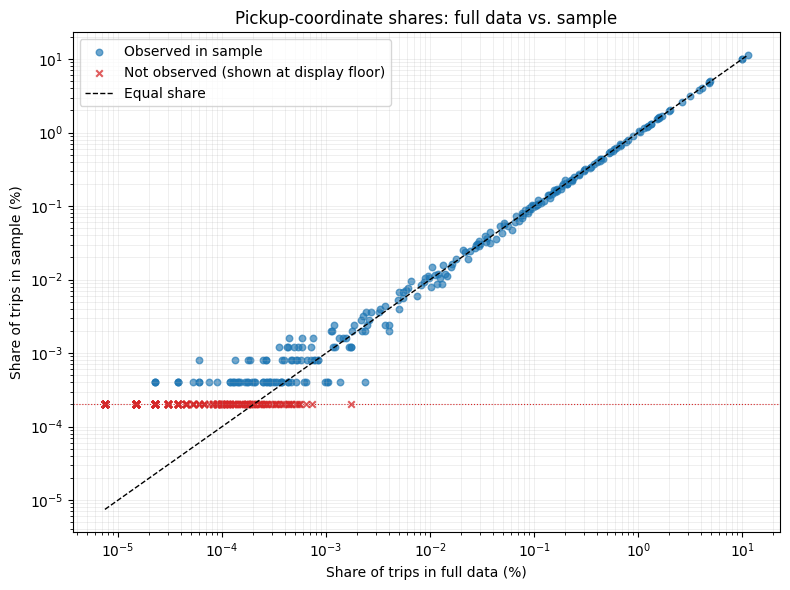

In [7]:
observed_mask = coordinate_comparison["observed_in_sample"]
full_share_pct = 100 * coordinate_comparison["full_trip_share"]
sample_share_pct = 100 * coordinate_comparison["sample_trip_share"]
display_floor_pct = 0.5 * 100 / SAMPLE_SIZE
sample_share_for_plot = sample_share_pct.mask(~observed_mask, display_floor_pct)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    full_share_pct[observed_mask],
    sample_share_pct[observed_mask],
    s=22,
    alpha=0.65,
    color="#1f77b4",
    label="Observed in sample",
)
ax.scatter(
    full_share_pct[~observed_mask],
    sample_share_for_plot[~observed_mask],
    s=22,
    alpha=0.75,
    color="#d62728",
    marker="x",
    label="Not observed (shown at display floor)",
)

line_min = full_share_pct.min()
line_max = max(full_share_pct.max(), sample_share_pct.max())
ax.plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle="--",
    color="black",
    linewidth=1,
    label="Equal share",
)
ax.axhline(
    display_floor_pct,
    color="#d62728",
    linestyle=":",
    linewidth=0.8,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Share of trips in full data (%)")
ax.set_ylabel("Share of trips in sample (%)")
ax.set_title("Pickup-coordinate shares: full data vs. sample")
ax.grid(True, which="both", linewidth=0.4, alpha=0.35)
ax.legend()
plt.tight_layout()
plt.show()

The sample contains 252 of 544 published coordinates (46.32%), but those coordinates account for 99.973% of all valid trips. The 292 omitted coordinates collectively represent only 0.027% of full demand. The Pearson correlation of the shares is 0.999970, showing that the dominant demand proportions are almost perfectly preserved. The lower Spearman correlation of 0.875716 reflects sampling noise, ties and zero counts among the extremely rare coordinates. A total variation distance of 0.602% indicates a small overall redistribution of probability mass. The sample is therefore highly representative for demand-hot-spot estimation, but not for an analysis whose objective is to represent every published coordinate at least once.

### Project pickup locations and construct the future GMM input

The geometry is first created in WGS84 from longitude and latitude and then projected. `X_gmm` contains exactly two columns: easting and northing in kilometres. Time, trip attributes, H3 cells and census identifiers are not GMM features.

In [8]:
pickup_gdf = gpd.GeoDataFrame(
    pickup_sample.copy(),
    geometry=gpd.points_from_xy(
        pickup_sample["pickup_longitude"],
        pickup_sample["pickup_latitude"],
        crs=SOURCE_CRS,
    ),
).to_crs(METRIC_CRS)

pickup_gdf["pickup_x_km"] = pickup_gdf.geometry.x / 1_000
pickup_gdf["pickup_y_km"] = pickup_gdf.geometry.y / 1_000

X_gmm = pickup_gdf[["pickup_x_km", "pickup_y_km"]].to_numpy(dtype=np.float64)

assert X_gmm.shape == (SAMPLE_SIZE, 2)
assert np.isfinite(X_gmm).all()

projection_summary = pd.DataFrame(
    {
        "minimum": X_gmm.min(axis=0),
        "mean": X_gmm.mean(axis=0),
        "maximum": X_gmm.max(axis=0),
        "standard_deviation": X_gmm.std(axis=0),
    },
    index=["pickup_x_km", "pickup_y_km"],
)
projection_summary

,minimum,mean,maximum,standard_deviation
pickup_x_km,424.312,441.975,455.498,9.405
pickup_y_km,"4,612.218","4,639.136","4,652.350",7.094


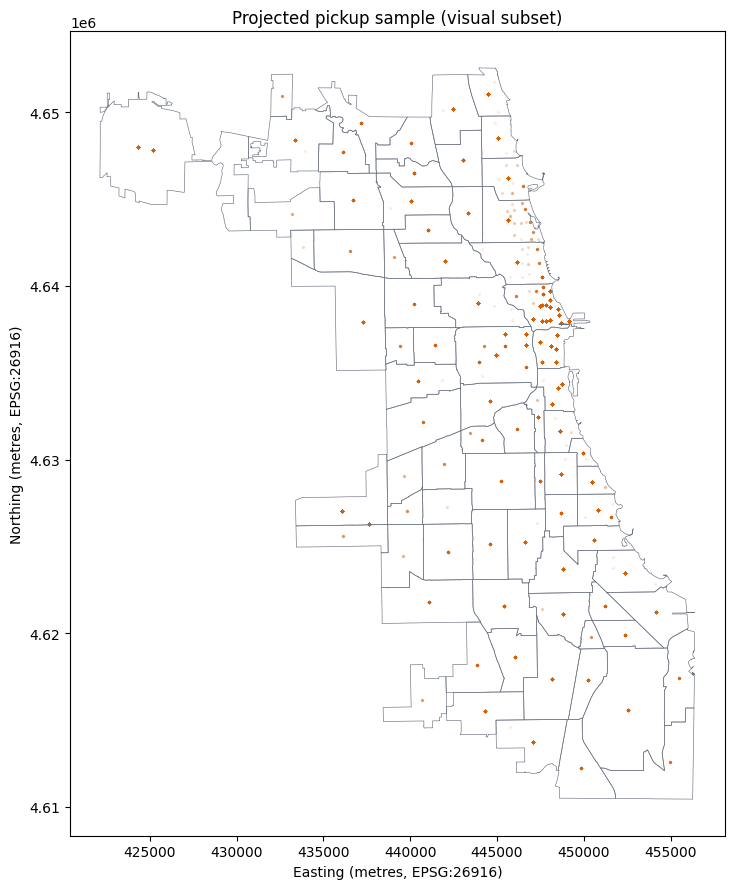

In [9]:
community_areas = gpd.read_parquet(COMMUNITY_PATH).to_crs(METRIC_CRS)
plot_points = pickup_gdf.sample(
    n=min(30_000, len(pickup_gdf)),
    random_state=RANDOM_SEED,
)

fig, ax = plt.subplots(figsize=(8, 9))
community_areas.boundary.plot(ax=ax, color="#6b7280", linewidth=0.45)
plot_points.plot(
    ax=ax,
    color="#d95f02",
    markersize=2,
    alpha=0.08,
    rasterized=True,
)
ax.set_title("Projected pickup sample (visual subset)")
ax.set_xlabel("Easting (metres, EPSG:26916)")
ax.set_ylabel("Northing (metres, EPSG:26916)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Train and compare candidate GMMs

Candidate models vary both the number of components and the covariance assumption. Every fit uses `init_params='kmeans'`

Coordinates are measured in kilometres, so `reg_covar=0.0001` corresponds to an added variance of 0.0001 km², or a standard-deviation floor of 0.01 km (10 m) along a collapsed axis. This is primarily numerical protection; components that reach this floor will be flagged as spatially questionable rather than silently accepted.

In [10]:
from time import perf_counter
import warnings

from sklearn.exceptions import ConvergenceWarning
from sklearn.mixture import GaussianMixture
from shapely.geometry import Point

COMPONENT_RANGE = range(2, 16)
COVARIANCE_TYPES = ("spherical", "diag", "tied", "full")
GMM_N_INIT = 5
GMM_MAX_ITER = 300
GMM_TOL = 1e-3
GMM_REG_COVAR = 1e-4  # km²; sqrt = 0.01 km = 10 m
SPATIAL_MIN_STD_KM = 0.05  # 50 m near-collapse screen for published centroids

print(
    f"Candidate fits: {len(COMPONENT_RANGE) * len(COVARIANCE_TYPES)} "
    f"({len(COMPONENT_RANGE)} K values × {len(COVARIANCE_TYPES)} covariance types)"
)

Candidate fits: 56 (14 K values × 4 covariance types)


In [11]:
def covariance_matrices(model):
    """Return one 2x2 covariance matrix per GMM component."""
    k = model.n_components
    if model.covariance_type == "full":
        return model.covariances_
    if model.covariance_type == "tied":
        return np.repeat(model.covariances_[None, :, :], k, axis=0)
    if model.covariance_type == "diag":
        return np.array([np.diag(values) for values in model.covariances_])
    if model.covariance_type == "spherical":
        return np.array([np.eye(2) * value for value in model.covariances_])
    raise ValueError(f"Unsupported covariance type: {model.covariance_type}")


def gmm_parameter_count(k, covariance_type, dimensions=2):
    weights = k - 1
    means = k * dimensions
    if covariance_type == "spherical":
        covariance = k
    elif covariance_type == "diag":
        covariance = k * dimensions
    elif covariance_type == "tied":
        covariance = dimensions * (dimensions + 1) // 2
    elif covariance_type == "full":
        covariance = k * dimensions * (dimensions + 1) // 2
    else:
        raise ValueError(covariance_type)
    return weights + means + covariance


community_union = community_areas.geometry.union_all()
candidate_models = {}
candidate_records = []

for covariance_type in COVARIANCE_TYPES:
    for k in COMPONENT_RANGE:
        model = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            init_params="kmeans",
            n_init=GMM_N_INIT,
            max_iter=GMM_MAX_ITER,
            tol=GMM_TOL,
            reg_covar=GMM_REG_COVAR,
            random_state=RANDOM_SEED,
        )

        started = perf_counter()
        with warnings.catch_warnings(record=True) as caught_warnings:
            warnings.simplefilter("always", ConvergenceWarning)
            model.fit(X_gmm)
        fit_seconds = perf_counter() - started

        covariance_array = covariance_matrices(model)
        eigenvalues = np.linalg.eigvalsh(covariance_array)
        component_min_std_km = np.sqrt(eigenvalues.min(axis=1))
        component_max_std_km = np.sqrt(eigenvalues.max(axis=1))
        means_inside = [
            community_union.covers(Point(mean_x * 1_000, mean_y * 1_000))
            for mean_x, mean_y in model.means_
        ]

        key = (covariance_type, k)
        candidate_models[key] = model
        candidate_records.append({
            "covariance_type": covariance_type,
            "n_components": k,
            "n_parameters": gmm_parameter_count(k, covariance_type),
            "converged": bool(model.converged_),
            "convergence_warning": any(
                issubclass(item.category, ConvergenceWarning) for item in caught_warnings
            ),
            "n_iter": model.n_iter_,
            "fit_seconds": fit_seconds,
            "mean_log_likelihood": model.score(X_gmm),
            "aic": model.aic(X_gmm),
            "bic": model.bic(X_gmm),
            "min_component_weight": model.weights_.min(),
            "min_component_std_km": component_min_std_km.min(),
            "max_component_std_km": component_max_std_km.max(),
            "components_at_variance_floor": int(
                np.sum(component_min_std_km <= np.sqrt(GMM_REG_COVAR) * 1.01)
            ),
            "components_below_50m_std": int(
                np.sum(component_min_std_km < SPATIAL_MIN_STD_KM)
            ),
            "component_means_outside_chicago": int(k - sum(means_inside)),
        })
    print(f"Finished covariance_type={covariance_type!r}")

candidate_results = pd.DataFrame(candidate_records)
candidate_results["aic_per_trip"] = candidate_results["aic"] / len(X_gmm)
candidate_results["bic_per_trip"] = candidate_results["bic"] / len(X_gmm)
candidate_results["delta_aic"] = candidate_results["aic"] - candidate_results["aic"].min()
candidate_results["delta_bic"] = candidate_results["bic"] - candidate_results["bic"].min()
candidate_results.sort_values(["bic", "aic"]).head(12)

Finished covariance_type='spherical'


Finished covariance_type='diag'


Finished covariance_type='tied'


Finished covariance_type='full'


,covariance_type,n_components,n_parameters,converged,convergence_warning,n_iter,fit_seconds,mean_log_likelihood,aic,bic,min_component_weight,min_component_std_km,max_component_std_km,components_at_variance_floor,components_below_50m_std,component_means_outside_chicago,aic_per_trip,bic_per_trip,delta_aic,delta_bic
52,full,12,71,True,False,21,11.429,-1.771,"885,589.874","886,330.348",0.012,0.010,5.728,7,7,0,3.542,3.545,0.000,0.000
55,full,15,89,True,False,25,9.490,-1.860,"930,164.090","931,092.290",0.012,0.010,7.880,6,7,0,3.721,3.724,"44,574.215","44,761.941"
54,full,14,83,True,False,12,12.026,-1.935,"967,867.632","968,733.257",0.004,0.010,5.785,5,5,0,3.871,3.875,"82,277.758","82,402.909"
53,full,13,77,True,False,19,13.185,-2.004,"1,002,352.697","1,003,155.746",0.012,0.010,6.476,6,7,0,4.009,4.013,"116,762.823","116,825.398"
26,diag,14,69,True,False,38,6.271,-2.196,"1,098,311.300","1,099,030.916",0.003,0.009,4.634,3,4,0,4.393,4.396,"212,721.426","212,700.568"
51,full,11,65,True,False,17,8.754,-2.197,"1,098,858.284","1,099,536.184",0.012,0.010,6.170,4,4,0,4.395,4.398,"213,268.410","213,205.835"
49,full,9,53,True,False,25,12.893,-2.292,"1,146,224.166","1,146,776.914",0.029,0.010,6.612,3,4,0,4.585,4.587,"260,634.292","260,446.566"
24,diag,12,59,True,False,18,4.981,-2.433,"1,216,718.181","1,217,333.504",0.011,0.008,5.151,3,3,0,4.867,4.869,"331,128.307","331,003.156"
50,full,10,59,True,False,28,8.940,-2.496,"1,248,130.093","1,248,745.416",0.012,0.010,5.513,3,4,0,4.993,4.995,"362,540.219","362,415.068"
27,diag,15,74,True,False,81,7.886,-2.545,"1,272,664.768","1,273,436.530",0.006,0.010,6.184,2,2,0,5.091,5.094,"387,074.894","387,106.182"


### AIC, BIC and convergence

AIC and BIC are evaluated on the same 250,000 observations, so their rankings are directly comparable. Lower values are better. Dividing by the number of trips only improves readability and does not change the ranking. The plots must be read together with convergence and spatial-degeneracy diagnostics.

In [12]:
convergence_summary = (
    candidate_results
    .groupby("covariance_type", as_index=False)
    .agg(
        fitted_models=("n_components", "size"),
        converged_models=("converged", "sum"),
        maximum_iterations=("n_iter", "max"),
        total_fit_seconds=("fit_seconds", "sum"),
        models_with_floor_components=("components_at_variance_floor", lambda s: (s > 0).sum()),
        models_with_below_50m_components=("components_below_50m_std", lambda s: (s > 0).sum()),
        models_with_outside_means=("component_means_outside_chicago", lambda s: (s > 0).sum()),
    )
)
convergence_summary

,covariance_type,fitted_models,converged_models,maximum_iterations,total_fit_seconds,models_with_floor_components,models_with_below_50m_components,models_with_outside_means
0,diag,14,14,81,57.695,7,7,0
1,full,14,14,35,108.528,14,14,0
2,spherical,14,14,63,65.285,7,9,0
3,tied,14,14,37,52.429,0,0,0


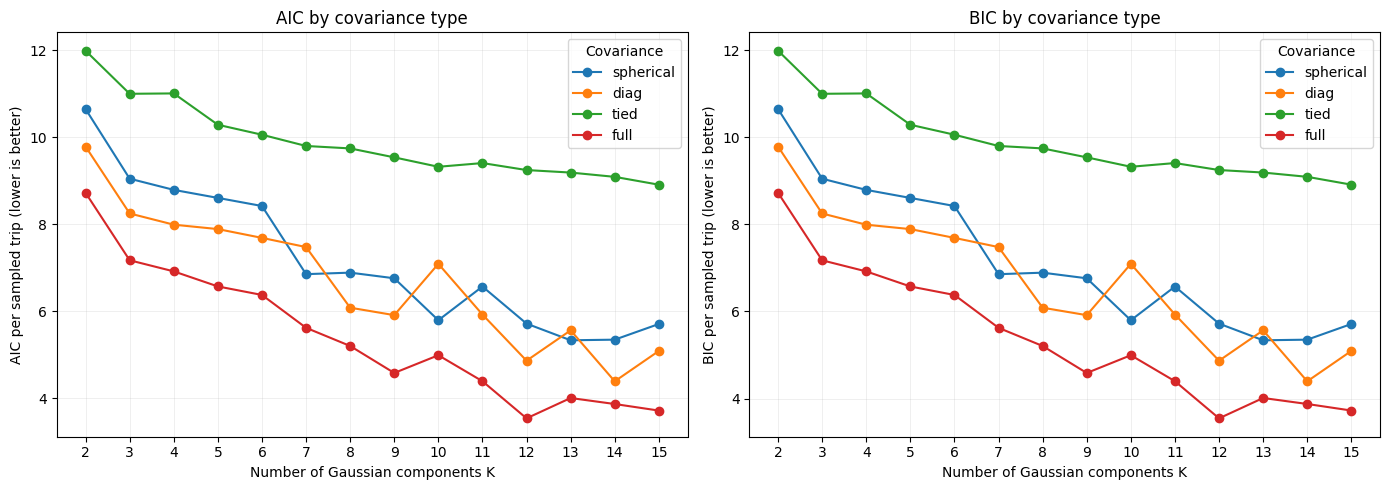

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for covariance_type in COVARIANCE_TYPES:
    subset = candidate_results[candidate_results["covariance_type"] == covariance_type]
    axes[0].plot(
        subset["n_components"], subset["aic_per_trip"],
        marker="o", label=covariance_type,
    )
    axes[1].plot(
        subset["n_components"], subset["bic_per_trip"],
        marker="o", label=covariance_type,
    )

axes[0].set_title("AIC by covariance type")
axes[0].set_ylabel("AIC per sampled trip (lower is better)")
axes[1].set_title("BIC by covariance type")
axes[1].set_ylabel("BIC per sampled trip (lower is better)")
for ax in axes:
    ax.set_xlabel("Number of Gaussian components K")
    ax.set_xticks(list(COMPONENT_RANGE))
    ax.grid(True, linewidth=0.4, alpha=0.35)
    ax.legend(title="Covariance")
plt.tight_layout()
plt.show()

In [14]:
selection_columns = [
    "covariance_type", "n_components", "n_parameters",
    "converged", "n_iter", "aic_per_trip", "bic_per_trip",
    "delta_aic", "delta_bic", "min_component_weight",
    "min_component_std_km", "components_at_variance_floor",
    "components_below_50m_std",
    "component_means_outside_chicago",
]
candidate_results.sort_values("bic")[selection_columns].head(15)

,covariance_type,n_components,n_parameters,converged,n_iter,aic_per_trip,bic_per_trip,delta_aic,delta_bic,min_component_weight,min_component_std_km,components_at_variance_floor,components_below_50m_std,component_means_outside_chicago
52,full,12,71,True,21,3.542,3.545,0.000,0.000,0.012,0.010,7,7,0
55,full,15,89,True,25,3.721,3.724,"44,574.215","44,761.941",0.012,0.010,6,7,0
54,full,14,83,True,12,3.871,3.875,"82,277.758","82,402.909",0.004,0.010,5,5,0
53,full,13,77,True,19,4.009,4.013,"116,762.823","116,825.398",0.012,0.010,6,7,0
26,diag,14,69,True,38,4.393,4.396,"212,721.426","212,700.568",0.003,0.009,3,4,0
51,full,11,65,True,17,4.395,4.398,"213,268.410","213,205.835",0.012,0.010,4,4,0
49,full,9,53,True,25,4.585,4.587,"260,634.292","260,446.566",0.029,0.010,3,4,0
24,diag,12,59,True,18,4.867,4.869,"331,128.307","331,003.156",0.011,0.008,3,3,0
50,full,10,59,True,28,4.993,4.995,"362,540.219","362,415.068",0.012,0.010,3,4,0
27,diag,15,74,True,81,5.091,5.094,"387,074.894","387,106.182",0.006,0.010,2,2,0


### Select the best plausible candidate

A candidate is considered spatially plausible for selection only if it converged, has no component mean outside the Chicago community-area union, and has no component with a narrowest standard deviation below 50 m. The 50 m screen is deliberately larger than the 10 m numerical floor: with privacy-protected repeated area centroids, a component this narrow describes an almost point-like published coordinate rather than a credible spatial hot spot. Among the candidates satisfying these predeclared safeguards, the model with the lowest BIC is selected.

In [15]:
candidate_results["plausible_for_selection"] = (
    candidate_results["converged"]
    & ~candidate_results["convergence_warning"]
    & candidate_results["components_below_50m_std"].eq(0)
    & candidate_results["component_means_outside_chicago"].eq(0)
)

raw_bic_winner = candidate_results.loc[candidate_results["bic"].idxmin()]
plausible_candidates = candidate_results[candidate_results["plausible_for_selection"]].copy()
if plausible_candidates.empty:
    raise RuntimeError("No candidate passed the spatial plausibility safeguards.")

selected_result = plausible_candidates.loc[plausible_candidates["bic"].idxmin()]
selected_key = (
    selected_result["covariance_type"],
    int(selected_result["n_components"]),
)
selected_gmm = candidate_models[selected_key]

selection_comparison = pd.DataFrame([
    {"selection": "Raw BIC minimum", **raw_bic_winner.to_dict()},
    {"selection": "Selected plausible model", **selected_result.to_dict()},
])[[
    "selection", "covariance_type", "n_components", "n_parameters",
    "converged", "n_iter", "aic_per_trip", "bic_per_trip",
    "min_component_weight", "min_component_std_km",
    "components_at_variance_floor", "components_below_50m_std",
    "component_means_outside_chicago",
]]
selection_comparison

,selection,covariance_type,n_components,n_parameters,converged,n_iter,aic_per_trip,bic_per_trip,min_component_weight,min_component_std_km,components_at_variance_floor,components_below_50m_std,component_means_outside_chicago
0,Raw BIC minimum,full,12,71,True,21,3.542,3.545,0.012,0.010,7,7,0
1,Selected plausible model,diag,10,49,True,20,7.093,7.095,0.026,0.071,0,0,0


In [16]:
plausible_ranking = plausible_candidates.sort_values("bic")[selection_columns].head(12)
plausible_ranking

,covariance_type,n_components,n_parameters,converged,n_iter,aic_per_trip,bic_per_trip,delta_aic,delta_bic,min_component_weight,min_component_std_km,components_at_variance_floor,components_below_50m_std,component_means_outside_chicago
22,diag,10,49,True,20,7.093,7.095,"887,545.232","887,315.789",0.026,0.071,0,0,0
19,diag,7,34,True,22,7.478,7.479,"983,906.848","983,520.967",0.029,0.071,0,0,0
18,diag,6,29,True,11,7.689,7.690,"1,036,644.629","1,036,206.601",0.029,0.071,0,0,0
17,diag,5,24,True,12,7.891,7.892,"1,087,167.663","1,086,677.490",0.029,0.071,0,0,0
16,diag,4,19,True,22,7.992,7.993,"1,112,512.647","1,111,970.328",0.134,0.072,0,0,0
15,diag,3,14,True,14,8.250,8.251,"1,176,921.225","1,176,326.759",0.215,0.071,0,0,0
4,spherical,6,23,True,26,8.422,8.423,"1,219,795.804","1,219,295.202",0.029,0.313,0,0,0
3,spherical,5,19,True,6,8.607,8.608,"1,266,252.070","1,265,709.751",0.119,0.313,0,0,0
2,spherical,4,15,True,5,8.792,8.793,"1,312,420.453","1,311,836.417",0.130,0.313,0,0,0
41,tied,15,47,True,10,8.911,8.913,"1,342,210.685","1,341,960.384",0.005,0.659,0,0,0


Both raw AIC and raw BIC favour the full-covariance model with K=12, but 7 of its 12 components collapse to the 10 m numerical variance floor. That solution is driven by repeated privacy-protected centroids and is rejected as a spatial hot-spot representation. All 56 candidates converged and none placed a mean outside Chicago. After applying the 50 m near-collapse screen, the lowest-BIC candidate is the diagonal-covariance model with K=10. It converged after 20 EM iterations, uses 49 parameters, has no component below the spatial screen, and its smallest component still represents 2.6% of sampled trips. Its narrowest component standard deviation is 0.071 km. `selected_gmm` therefore refers to `diag`, K=10 for the next spatial visualisation and interpretation step. Because a diagonal covariance cannot rotate its ellipses, the eventual map remains an essential substantive check of this statistically and diagnostically selected model.

### selected components

Components are relabelled by descending mixture weight so that component 1 always represents the largest share of sampled demand. The component mean is spatially joined to a Chicago community area for orientation. The 95% ellipse is a common probability contour, not a hard cluster boundary. Its area measures spatial spread, while the weighted component density at the mean combines spread and mixture weight into a concentration measure.

In [17]:
from matplotlib.colors import LogNorm
from matplotlib.patches import Ellipse
from shapely import contains_xy

CHI2_95_DF2 = 5.991464547
selected_covariances = covariance_matrices(selected_gmm)
component_order = np.argsort(selected_gmm.weights_)[::-1]
full_valid_trips = int(source_summary.loc[0, "trips_with_valid_pickup"])

component_records = []
for display_id, model_index in enumerate(component_order, start=1):
    covariance = selected_covariances[model_index]
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    eigen_order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[eigen_order]
    eigenvectors = eigenvectors[:, eigen_order]
    major_std_km, minor_std_km = np.sqrt(eigenvalues)
    angle_deg = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    ellipse_area_95_km2 = np.pi * CHI2_95_DF2 * np.sqrt(np.linalg.det(covariance))
    weight = selected_gmm.weights_[model_index]
    component_peak_density = weight / (2 * np.pi * np.sqrt(np.linalg.det(covariance)))
    mean_x_km, mean_y_km = selected_gmm.means_[model_index]

    component_records.append({
        "component": display_id,
        "model_index": model_index,
        "weight": weight,
        "sample_trips_effective": weight * len(X_gmm),
        "full_trips_estimated": weight * full_valid_trips,
        "mean_x_km": mean_x_km,
        "mean_y_km": mean_y_km,
        "major_std_km": major_std_km,
        "minor_std_km": minor_std_km,
        "axis_ratio": major_std_km / minor_std_km,
        "angle_deg": angle_deg,
        "ellipse_area_95_km2": ellipse_area_95_km2,
        "weighted_peak_density_per_km2": component_peak_density,
    })

component_table = pd.DataFrame(component_records)
component_points = gpd.GeoDataFrame(
    component_table.copy(),
    geometry=gpd.points_from_xy(
        component_table["mean_x_km"] * 1_000,
        component_table["mean_y_km"] * 1_000,
    ),
    crs=METRIC_CRS,
)
component_points = gpd.sjoin(
    component_points,
    community_areas[["COMMUNITY", "geometry"]],
    how="left",
    predicate="within",
).drop_duplicates(subset="component")
component_table = (
    component_table
    .merge(component_points[["component", "COMMUNITY"]], on="component", how="left")
    .rename(columns={"COMMUNITY": "community_area_at_mean"})
)

component_display_columns = [
    "component", "community_area_at_mean", "weight",
    "sample_trips_effective", "full_trips_estimated",
    "major_std_km", "minor_std_km", "axis_ratio",
    "ellipse_area_95_km2", "weighted_peak_density_per_km2",
]
component_table[component_display_columns]

,component,community_area_at_mean,weight,sample_trips_effective,full_trips_estimated,major_std_km,minor_std_km,axis_ratio,ellipse_area_95_km2,weighted_peak_density_per_km2
0,1,OHARE,0.215,"53,676.000","2,874,368.238",0.437,0.071,6.118,0.588,1.094
1,2,NEAR WEST SIDE,0.203,"50,824.845","2,721,687.924",1.153,0.367,3.140,7.963,0.076
2,3,NEAR NORTH SIDE,0.173,"43,273.598","2,317,316.034",0.413,0.285,1.451,2.216,0.234
3,4,LOOP,0.144,"36,096.739","1,932,992.790",1.902,0.123,15.408,4.419,0.098
4,5,LAKE VIEW,0.067,"16,698.986","894,236.434",1.757,0.240,7.332,7.923,0.025
5,6,WEST TOWN,0.064,"15,956.395","854,470.443",4.616,3.391,1.361,294.570,0.001
6,7,WASHINGTON PARK,0.048,"11,895.386","637,002.006",3.555,1.895,1.876,126.818,0.001
7,8,WEST RIDGE,0.031,"7,718.969","413,353.456",3.542,1.337,2.650,89.113,0.001
8,9,GARFIELD RIDGE,0.029,"7,326.869","392,356.364",0.790,0.381,2.073,5.662,0.016
9,10,ROSELAND,0.026,"6,532.214","349,802.312",3.739,3.640,1.027,256.122,0.000


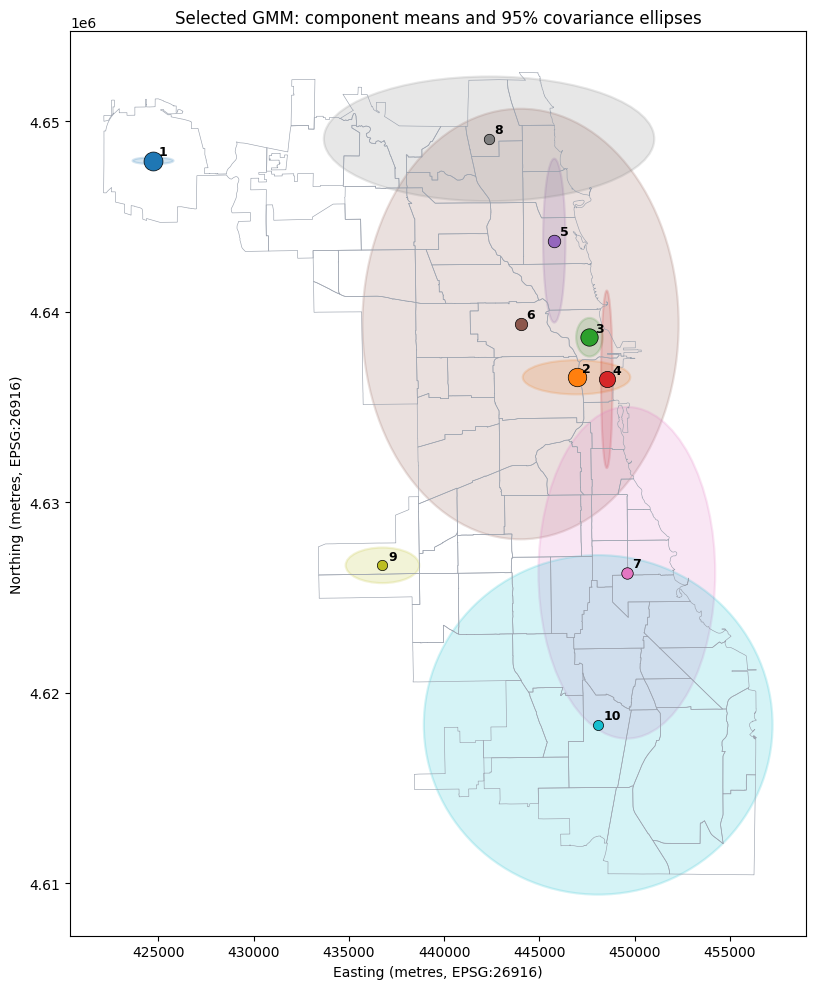

In [18]:
fig, ax = plt.subplots(figsize=(9, 10))
community_areas.boundary.plot(ax=ax, color="#9ca3af", linewidth=0.45)
colors = plt.cm.tab10(np.linspace(0, 1, len(component_table)))

for row, color in zip(component_table.itertuples(), colors):
    ellipse = Ellipse(
        xy=(row.mean_x_km * 1_000, row.mean_y_km * 1_000),
        width=2 * np.sqrt(CHI2_95_DF2) * row.major_std_km * 1_000,
        height=2 * np.sqrt(CHI2_95_DF2) * row.minor_std_km * 1_000,
        angle=row.angle_deg,
        facecolor=color,
        edgecolor=color,
        alpha=0.18,
        linewidth=1.6,
    )
    ax.add_patch(ellipse)
    ax.scatter(
        row.mean_x_km * 1_000, row.mean_y_km * 1_000,
        s=35 + 700 * row.weight, color=color, edgecolor="black", linewidth=0.5, zorder=3,
    )
    ax.annotate(
        str(row.component),
        (row.mean_x_km * 1_000, row.mean_y_km * 1_000),
        xytext=(4, 4), textcoords="offset points", fontsize=9, weight="bold",
    )

ax.set_title("Selected GMM: component means and 95% covariance ellipses")
ax.set_xlabel("Easting (metres, EPSG:26916)")
ax.set_ylabel("Northing (metres, EPSG:26916)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Overall GMM density and hot-spot map

The component ellipses describe individual mixture terms, the hot-spot surface is their weighted sum. The selected GMM is evaluated on a regular 200 m grid. Values are probability density per km² and the surface is clipped to the Chicago community-area union. A logarithmic colour scale is used because concentrated and diffuse demand differ by several orders of magnitude. Gaussian tails outside Chicago still exist mathematically but are not shown or renormalised.

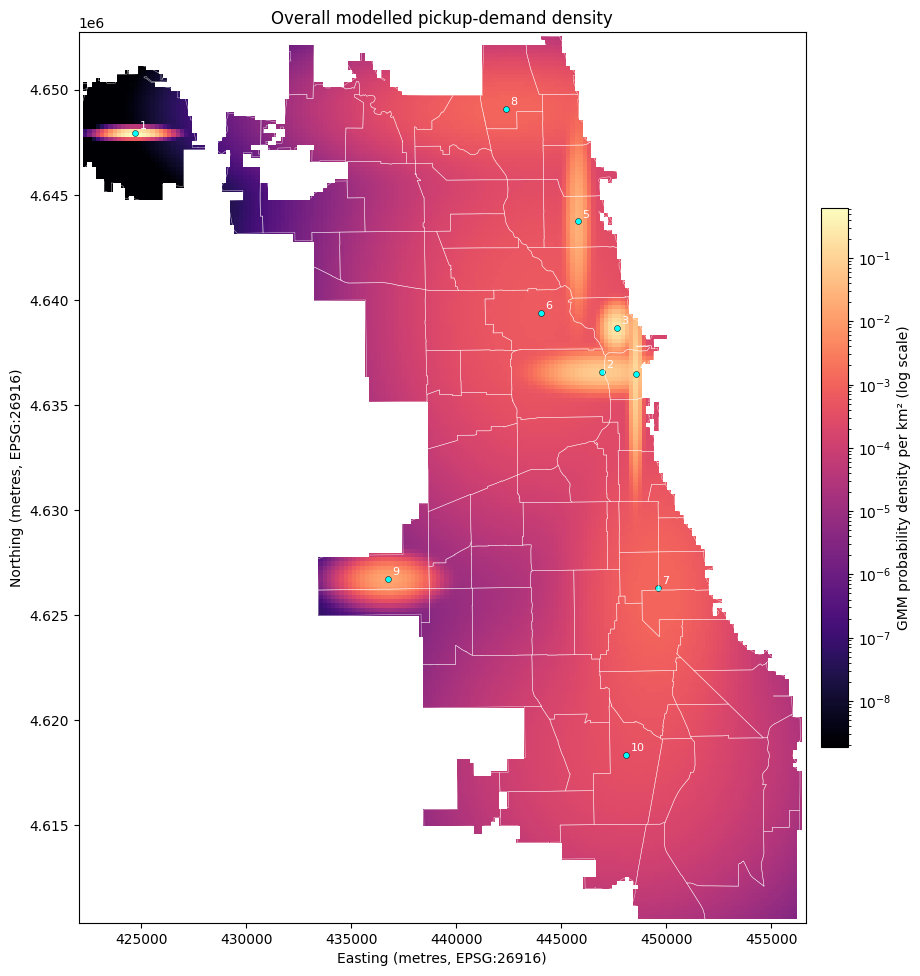

In [19]:
GRID_STEP_KM = 0.2
min_x_m, min_y_m, max_x_m, max_y_m = community_areas.total_bounds
grid_x_km = np.arange(min_x_m / 1_000, max_x_m / 1_000 + GRID_STEP_KM, GRID_STEP_KM)
grid_y_km = np.arange(min_y_m / 1_000, max_y_m / 1_000 + GRID_STEP_KM, GRID_STEP_KM)
grid_xx_km, grid_yy_km = np.meshgrid(grid_x_km, grid_y_km)
grid_coordinates_km = np.column_stack([grid_xx_km.ravel(), grid_yy_km.ravel()])
inside_chicago = contains_xy(
    community_union,
    grid_coordinates_km[:, 0] * 1_000,
    grid_coordinates_km[:, 1] * 1_000,
)

overall_density_flat = np.exp(selected_gmm.score_samples(grid_coordinates_km))
overall_density_flat[~inside_chicago] = np.nan
overall_density = overall_density_flat.reshape(grid_xx_km.shape)
positive_overall_density = overall_density_flat[np.isfinite(overall_density_flat) & (overall_density_flat > 0)]
overall_norm = LogNorm(
    vmin=np.quantile(positive_overall_density, 0.02),
    vmax=positive_overall_density.max(),
)

fig, ax = plt.subplots(figsize=(9, 10))
density_mesh = ax.pcolormesh(
    grid_xx_km * 1_000, grid_yy_km * 1_000, overall_density,
    shading="auto", cmap="magma", norm=overall_norm, rasterized=True,
)
community_areas.boundary.plot(ax=ax, color="white", linewidth=0.35, alpha=0.75)
for row in component_table.itertuples():
    ax.scatter(row.mean_x_km * 1_000, row.mean_y_km * 1_000, s=18, color="cyan", edgecolor="black", linewidth=0.35)
    ax.annotate(str(row.component), (row.mean_x_km * 1_000, row.mean_y_km * 1_000), xytext=(3, 3), textcoords="offset points", color="white", fontsize=8)

colorbar = fig.colorbar(density_mesh, ax=ax, fraction=0.035, pad=0.02)
colorbar.set_label("GMM probability density per km² (log scale)")
ax.set_title("Overall modelled pickup-demand density")
ax.set_xlabel("Easting (metres, EPSG:26916)")
ax.set_ylabel("Northing (metres, EPSG:26916)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

In [20]:
overall_peak_flat_index = int(np.nanargmax(overall_density_flat))
overall_peak_point = gpd.GeoDataFrame(
    {"peak_density_per_km2": [overall_density_flat[overall_peak_flat_index]]},
    geometry=[Point(
        grid_coordinates_km[overall_peak_flat_index, 0] * 1_000,
        grid_coordinates_km[overall_peak_flat_index, 1] * 1_000,
    )],
    crs=METRIC_CRS,
)
overall_peak_summary = gpd.sjoin(
    overall_peak_point,
    community_areas[["COMMUNITY", "geometry"]],
    how="left", predicate="within",
).rename(columns={"COMMUNITY": "community_area"})
overall_peak_summary[["community_area", "peak_density_per_km2"]]

,community_area,peak_density_per_km2
0,OHARE,0.611


## Compare four equal temporal windows

Four six-hour windows cover the full day: night (00:00–05:59), morning (06:00–11:59), afternoon (12:00–17:59), and evening (18:00–23:59). The selected structure (`diag`, K=10) is held fixed to make maps comparable. Each temporal model receives its own K-Means-based initialisation and five starts. A 50 m covariance floor is enforced for these subgroup fits because smaller subsets are especially susceptible to collapsing onto repeated published centroids.

The maps show joint demand density, `P(time window) × p(location | time window)`, on one common logarithmic scale. They therefore reflect both the spatial pattern within a window and its share of all sampled trips. Since the windows have equal duration, their levels are directly comparable.

In [21]:
TIME_WINDOWS = [
    ("Night (00–06)", 0, 6),
    ("Morning (06–12)", 6, 12),
    ("Afternoon (12–18)", 12, 18),
    ("Evening (18–24)", 18, 24),
]
TEMPORAL_REG_COVAR = SPATIAL_MIN_STD_KM ** 2
pickup_hours = pickup_gdf["trip_start_timestamp"].dt.hour
temporal_models = {}
temporal_density_surfaces = {}
temporal_records = []

for window_name, start_hour, end_hour in TIME_WINDOWS:
    window_mask = pickup_hours.between(start_hour, end_hour - 1)
    X_window = pickup_gdf.loc[window_mask, ["pickup_x_km", "pickup_y_km"]].to_numpy()
    window_share = len(X_window) / len(X_gmm)

    temporal_model = GaussianMixture(
        n_components=selected_gmm.n_components,
        covariance_type=selected_gmm.covariance_type,
        init_params="kmeans",
        n_init=GMM_N_INIT,
        max_iter=GMM_MAX_ITER,
        tol=GMM_TOL,
        reg_covar=TEMPORAL_REG_COVAR,
        random_state=RANDOM_SEED,
    ).fit(X_window)
    temporal_models[window_name] = temporal_model

    joint_density_flat = window_share * np.exp(temporal_model.score_samples(grid_coordinates_km))
    joint_density_flat[~inside_chicago] = np.nan
    temporal_density_surfaces[window_name] = joint_density_flat.reshape(grid_xx_km.shape)
    peak_index = int(np.nanargmax(joint_density_flat))

    temporal_covariances = covariance_matrices(temporal_model)
    temporal_min_std = np.sqrt(np.linalg.eigvalsh(temporal_covariances).min())
    temporal_records.append({
        "time_window": window_name,
        "sampled_trips": len(X_window),
        "share_of_all_sampled_trips": window_share,
        "converged": temporal_model.converged_,
        "n_iter": temporal_model.n_iter_,
        "minimum_component_std_km": temporal_min_std,
        "largest_component_weight": temporal_model.weights_.max(),
        "peak_x_km": grid_coordinates_km[peak_index, 0],
        "peak_y_km": grid_coordinates_km[peak_index, 1],
        "peak_joint_density_per_km2": joint_density_flat[peak_index],
    })

temporal_summary = pd.DataFrame(temporal_records)
temporal_peak_points = gpd.GeoDataFrame(
    temporal_summary.copy(),
    geometry=gpd.points_from_xy(
        temporal_summary["peak_x_km"] * 1_000,
        temporal_summary["peak_y_km"] * 1_000,
    ),
    crs=METRIC_CRS,
)
temporal_peak_points = gpd.sjoin(
    temporal_peak_points,
    community_areas[["COMMUNITY", "geometry"]],
    how="left", predicate="within",
).drop_duplicates(subset="time_window")
temporal_summary = (
    temporal_summary
    .merge(temporal_peak_points[["time_window", "COMMUNITY"]], on="time_window", how="left")
    .rename(columns={"COMMUNITY": "peak_community_area"})
)
temporal_summary

,time_window,sampled_trips,share_of_all_sampled_trips,converged,n_iter,minimum_component_std_km,largest_component_weight,peak_x_km,peak_y_km,peak_joint_density_per_km2,peak_community_area
0,Night (00–06),11354,0.045,True,20,0.050,0.291,447.531,"4,638.845",0.241,NEAR NORTH SIDE
1,Morning (06–12),71255,0.285,True,25,0.050,0.195,444.931,"4,636.045",0.496,NEAR WEST SIDE
2,Afternoon (12–18),102135,0.409,True,20,0.050,0.414,447.531,"4,638.845",1.076,NEAR NORTH SIDE
3,Evening (18–24),65256,0.261,True,17,0.050,0.320,447.531,"4,638.845",0.782,NEAR NORTH SIDE


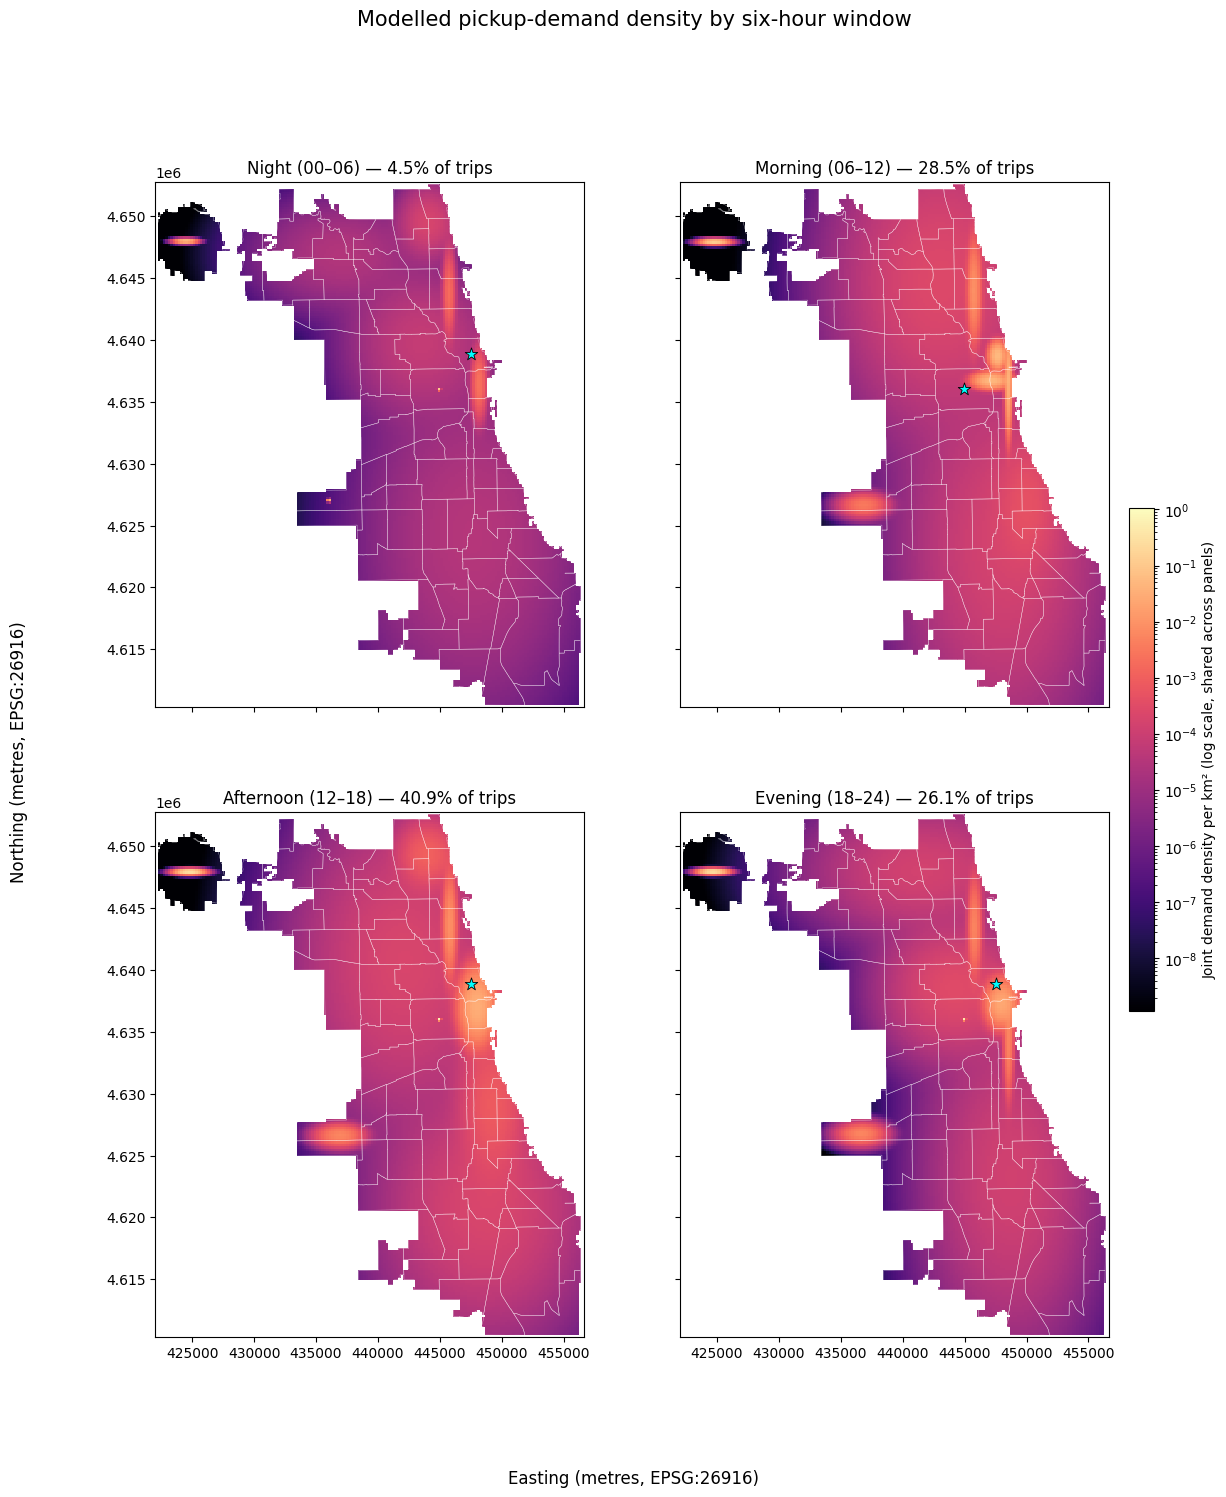

In [22]:
all_temporal_positive = np.concatenate([
    surface[np.isfinite(surface) & (surface > 0)]
    for surface in temporal_density_surfaces.values()
])
temporal_norm = LogNorm(
    vmin=np.quantile(all_temporal_positive, 0.02),
    vmax=all_temporal_positive.max(),
)

fig, axes = plt.subplots(2, 2, figsize=(13, 15), sharex=True, sharey=True)
last_mesh = None
for ax, (window_name, _, _) in zip(axes.ravel(), TIME_WINDOWS):
    surface = temporal_density_surfaces[window_name]
    last_mesh = ax.pcolormesh(
        grid_xx_km * 1_000, grid_yy_km * 1_000, surface,
        shading="auto", cmap="magma", norm=temporal_norm, rasterized=True,
    )
    community_areas.boundary.plot(ax=ax, color="white", linewidth=0.3, alpha=0.7)
    peak_row = temporal_summary.loc[temporal_summary["time_window"] == window_name].iloc[0]
    ax.scatter(peak_row["peak_x_km"] * 1_000, peak_row["peak_y_km"] * 1_000, marker="*", s=90, color="cyan", edgecolor="black", linewidth=0.6)
    ax.set_title(f"{window_name} — {peak_row['share_of_all_sampled_trips']:.1%} of trips")
    ax.set_aspect("equal")

fig.supxlabel("Easting (metres, EPSG:26916)")
fig.supylabel("Northing (metres, EPSG:26916)")
colorbar = fig.colorbar(last_mesh, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
colorbar.set_label("Joint demand density per km² (log scale, shared across panels)")
fig.suptitle("Modelled pickup-demand density by six-hour window", y=0.995, fontsize=15)
plt.show()

## results and limitations

The analysis uses a reproducible, demand-preserving reservoir sample of 250,000 trip-level pickup centroids and projects them to EPSG:26916. Candidate Gaussian mixture models combine K=2–15 with four covariance assumptions. Each candidate uses K-Means-based initialisation, five starts and EM estimation. AIC, BIC, convergence and spatial degeneracy are compared. The raw information-criterion winner is rejected when components collapse onto repeated privacy centroids; the selected plausible model is `diag`, K=10. Components are summarised through weights, means, covariance-derived 95% ellipses and density. The overall hot-spot surface is the sum of all weighted Gaussian components. Four fixed six-hour subgroup models provide a comparable temporal extension.

### Results

The selected model separates concentrated demand centres from broad background patterns. The largest component is centred in O'Hare and represents 21.5% of sampled demand. Its 95% ellipse covers only 0.59 km² and its weighted component peak density is 1.094 per km², making it both the largest component and the strongest local concentration. This unusually sharp airport component must also be understood as a consequence of many trips sharing published airport centroids. The next largest components are centred in Near West Side (20.3%), Near North Side (17.3%) and Loop (14.4%). Near North Side is more locally concentrated than Near West Side despite its lower weight. The Loop component is extremely elongated, with an axis ratio of 15.4, while Lake View is also elongated with an axis ratio of 7.3. Because the selected covariance is diagonal, these elongations remain aligned with the coordinate axes and cannot represent an arbitrary diagonal corridor.

Components centred in West Town, Washington Park, West Ridge and Roseland have much larger 95% ellipse areas, ranging from about 89 to 295 km². They are better interpreted as diffuse regional demand terms than as sharply bounded local hot spots. A smaller compact component in Garfield Ridge accounts for 2.9% of demand and is consistent with a separate concentration around the Midway-airport area. The summed density surface reaches its grid maximum in O'Hare. It additionally shows strong concentrations around Near West Side, Near North Side, Loop and the north lakefront, plus a distinct Garfield Ridge concentration. These locations describe modelled pickup concentration, not exact pickup addresses or taxi routes.

The equal six-hour windows contain 4.5% of sampled trips at night, 28.5% in the morning, 40.9% in the afternoon and 26.1% in the evening. All four temporal models converge. The modelled grid maximum lies in Near North Side during the night, afternoon and evening, while the morning maximum moves to Near West Side. The afternoon has both the largest trip share and the highest joint peak density; the evening retains a strong Near North Side concentration. O'Hare remains visually prominent across the temporal maps, and the Garfield Ridge concentration is also visible in the daytime panels. Commuting, airport operations, tourism and nightlife are plausible explanations for these shifts, but the taxi data alone do not establish those causes. Each temporal model reaches the imposed 50 m covariance floor, confirming that repeated published centroids remain influential even after temporal subdivision.

### Interpretation rules

A high component weight means a large share of all sampled trips; it does not automatically imply the highest local density. A small ellipse with moderate weight may form a stronger local hot spot than a broad ellipse with a larger weight. Component boundaries are probabilistic and overlapping, while the summed density surface is the primary hot-spot result. Community-area names describe the location of a component mean or grid maximum, not the full extent of a component.

### Limitations

- The source contains 13.4 million trips but only 544 distinct published pickup coordinates. These are privacy-protected area centroids, not exact addresses.
- Repeated centroids carry valid demand-frequency information but can cause nearly singular Gaussian components. The 50 m screen and temporal covariance floor are modelling safeguards, not measurements of true positional error.
- AIC and BIC strongly reward narrow components at repeated coordinates; their raw minimum is therefore not accepted without spatial diagnostics.
- The selected diagonal covariance permits different horizontal and vertical spread but no rotated ellipse. This is less flexible than `full` covariance, which was rejected because every tested full model contained near-collapsed components.
- Gaussian distributions have unbounded tails. The maps clip values outside Chicago but do not boundary-correct or renormalise the density.
- Components are mathematical density terms, not administrative units, routes or causal neighbourhood definitions.
- The temporal windows are deliberately simple and the same model structure is imposed for comparability; they are not separately selected optimal models.
- The analysis identifies associations and concentrations. Explanations involving airports, commuting, nightlife or traffic remain plausible interpretations rather than causal evidence.